# Drug Side Effect Analysis

## Project Objective
The objective of this project is to analyze adverse drug event reports using FAERS-style real-world data. The project focuses on identifying commonly reported adverse reactions, exploring how reports vary across different patient groups, and understanding patterns related to patient sex, age, reporting country, and seriousness of the reports.

This analysis also aims to practice core data analysis skills in Python, including data cleaning, handling missing values, extracting information from nested fields, grouping data, creating pivot tables, and visualizing patterns in the dataset.

## Project Background
Adverse drug reactions are unwanted or harmful effects that may occur after taking a medication. Monitoring these reactions is an important part of drug safety and pharmacovigilance. Real-world adverse event reporting systems, such as FAERS, collect reports from healthcare professionals, patients, and manufacturers to help identify possible safety signals related to medications.

Because real-world health data can be messy, this type of dataset provides a useful opportunity to practice data cleaning and exploratory data analysis while working on a topic related to pharmacy and drug safety.

## Dataset Description
The dataset contains adverse drug event reports with information such as safety report ID, transmission date, received date, patient age, patient sex, reporter country, seriousness indicators, reported reactions, and drug details.

Some fields, such as reported reactions and drug details, may contain multiple values within a single report. Therefore, part of the analysis will involve cleaning and transforming these columns into a more usable format for analysis.

## Main Questions

- What are the most commonly reported adverse reactions?
- Which drugs are most frequently mentioned in reports?
- How do reports differ by patient sex and age?
- Which countries report the most adverse events?
- How many reports are serious, and what reactions are common among serious reports?

## setup
In this section, the required libraries are imported and basic settings are configured.

In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
df=pd.read_csv(r"C:\Users\Lapfix.ir\Documents\data_analyse.pj\jp notebook\ Drug Side Effect Analysis\notebook\data\drug_event_reports.csv")

## Initial Data Inspection

### 5.1 Previewing the Data

In [ ]:
display(df.head())
display(df.shape)

### 5.2 Dataset Information & Data Types

In [ ]:
df.info()

### 5.3 Missing Values Analysis

In [ ]:
df.isna().sum()

### 5.4 Exploring Unique Values (Sex & Seriousness)

In [ ]:
display(df['sex'].value_counts(dropna=False))
df['serious'].value_counts(dropna=False)

### 5.5 Inspecting Nested Columns (Drug Details & Reactions)

In [ ]:
pd.set_option('display.max_colwidth', None)
for i in df['drug_details'].head(3):
    print(i)
    print()
pd.set_option('display.max_colwidth', 50)

In [ ]:
for r in df['reactions'].head(5):
    print(r)
    print()


The `Reactions` column contains one or more adverse reactions per report. Multiple reactions appear to be separated by semicolons (`;`). Therefore, this column will need to be split and expanded in later steps for reaction-level analysis.

The `Drug Details` column contains nested drug information in a list/dictionary-like format, including fields such as `drug_name`, `drug_indication`, and `administration_route`. This structure will need to be parsed later to extract useful features such as the drug name.


## Data Cleaning

In [ ]:
display(df['transmission_date'].head(3))
print()
display(df['received_date'].head(3))

In [43]:
df['transmission_date'] = pd.to_datetime(df['transmission_date'].astype(str), format='%Y%m%d')
df['received_date'] = pd.to_datetime(df['received_date'].astype(str), format='%Y%m%d')

In [42]:
df=df.rename(columns={'Safety Report ID':'safety_report_id',
          'Transmission Date':'transmission_date',
                  'Serious':'serious',
                   'Seriousness Death':'seriousness_death',
                   'Received Date':'received_date',
                   'Patient Age':'age',
                   'Patient Sex':'sex',
                   'Reporter Country':'reporter_country',
                   'Reactions':'reactions',
                   'Drug Details':'drug_details'
})
#بعدا تمررین بشه تابغ=عی با این ویزگی برای نمودارای بزرگتر گرفته بشه


In [44]:
df.head()

,safety_report_id,transmission_date,serious,seriousness_death,received_date,age,sex,reporter_country,reactions,drug_details
0,5801206-7,2009-01-09,1,1.0,2008-07-07,26.0,1.0,CANADA,DRUG ADMINISTRATION ERROR; OVERDOSE,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati..."
1,10003300,2014-10-02,1,NaN,2014-03-06,77.0,2.0,US,Vomiting; Diarrhoea; Arthralgia; Headache,"[{'drug_name': 'BONIVA', 'drug_indication': 'O..."
2,10003301,2014-10-02,1,NaN,2014-02-28,NaN,2.0,US,Dyspepsia; Renal impairment,"[{'drug_name': 'IBUPROFEN', 'drug_indication':..."
3,10003302,2014-10-02,2,NaN,2014-03-12,NaN,1.0,US,Drug ineffective,"[{'drug_name': 'LYRICA', 'drug_indication': No..."
4,10003304,2014-12-12,2,NaN,2014-03-12,NaN,2.0,US,Drug hypersensitivity,"[{'drug_name': 'DOXYCYCLINE HYCLATE', 'drug_in..."


In [45]:
#checking sex serious and seriousness_death columns value counts for later data cleaning purposes
display(df['sex'].value_counts(dropna=False))
print()
display(df['serious'].value_counts(dropna=False))
print
df['seriousness_death'].value_counts(dropna=False)

sex
2.0    5808
1.0    3195
0.0     923
NaN      74
Name: count, dtype: int64

serious
1    5358
2    4642
Name: count, dtype: int64

seriousness_death
NaN    9293
1.0     701
2.0       6
Name: count, dtype: int64

In [46]:
#transforing numbers into meaningfull words for later analyses 
df['serious']=np.where(df['serious']==1,'Serious','Not Serious')  
seriousness_death_map={1:'Death',2:'No death',np.nan:'Not reported'}
df['seriousness_death']=df['seriousness_death'].map(seriousness_death_map)
sex_map={1:'Male',2:'Female',0:'Unknown',np.nan:'Missing'}
df['sex']=df['sex'].map(sex_map)

In [47]:
df.head()

,safety_report_id,transmission_date,serious,seriousness_death,received_date,age,sex,reporter_country,reactions,drug_details
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,DRUG ADMINISTRATION ERROR; OVERDOSE,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati..."
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Vomiting; Diarrhoea; Arthralgia; Headache,"[{'drug_name': 'BONIVA', 'drug_indication': 'O..."
2,10003301,2014-10-02,Serious,Not reported,2014-02-28,NaN,Female,US,Dyspepsia; Renal impairment,"[{'drug_name': 'IBUPROFEN', 'drug_indication':..."
3,10003302,2014-10-02,Not Serious,Not reported,2014-03-12,NaN,Male,US,Drug ineffective,"[{'drug_name': 'LYRICA', 'drug_indication': No..."
4,10003304,2014-12-12,Not Serious,Not reported,2014-03-12,NaN,Female,US,Drug hypersensitivity,"[{'drug_name': 'DOXYCYCLINE HYCLATE', 'drug_in..."


In [48]:
#inspecting genaral information about age column like min and max to check there is no weird age and if there is tranferring it into nan value for later data cleaning steps
print((df['age'].max()))
print(df['age'].min())
print(df['age'].isna().sum())
print((df['age']>120).sum())
df['age']=np.where(df['age']>120,np.nan,df['age'])

22240.0
0.0
3350
4


In [49]:
#transforing numbers into meaningfull words for later analyses 
def age_group(age):
    if pd.isna(age):
        return 'unknown'
    elif age <= 12:
        return 'Child'
    elif age <= 18:
        return 'Adolescent'
    elif age <= 40:
        return 'Young Adults'
    elif age <= 65:
        return 'Middle Age'
    else:
        return 'Senior'

df = df.assign(age_group=df['age'].apply(age_group))


In [50]:
#for checking if all ages are in groups and there is no weird grouping or result
a=df['age_group'].value_counts()
total=a.sum()
for index,value in a.items():
    print (f'{index} : {value/total*100:.2f}%')

unknown : 33.54%
Middle Age : 28.54%
Senior : 25.88%
Young Adults : 8.65%
Child : 2.27%
Adolescent : 1.12%


In [51]:
df.head()

,safety_report_id,transmission_date,serious,seriousness_death,received_date,age,sex,reporter_country,reactions,drug_details,age_group
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,DRUG ADMINISTRATION ERROR; OVERDOSE,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Vomiting; Diarrhoea; Arthralgia; Headache,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior
2,10003301,2014-10-02,Serious,Not reported,2014-02-28,NaN,Female,US,Dyspepsia; Renal impairment,"[{'drug_name': 'IBUPROFEN', 'drug_indication':...",unknown
3,10003302,2014-10-02,Not Serious,Not reported,2014-03-12,NaN,Male,US,Drug ineffective,"[{'drug_name': 'LYRICA', 'drug_indication': No...",unknown
4,10003304,2014-12-12,Not Serious,Not reported,2014-03-12,NaN,Female,US,Drug hypersensitivity,"[{'drug_name': 'DOXYCYCLINE HYCLATE', 'drug_in...",unknown


In [52]:
report_level_df=df.copy()

In [53]:
#seprating reactions for each drug to different columns 
def splitting_reactions(reactions):
    if pd.isna(reactions):
        return []
    else:
         return [x.strip() for x in reactions.split(';')  if x.strip()]
df['reactions']=df['reactions'].apply(splitting_reactions)

In [54]:
df = df.explode('reactions')
print(df.shape)
df=df.rename(columns={'reactions':'reaction'})
df.head()

(26687, 11)


,safety_report_id,transmission_date,serious,seriousness_death,received_date,age,sex,reporter_country,reaction,drug_details,age_group
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,DRUG ADMINISTRATION ERROR,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,OVERDOSE,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Vomiting,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Diarrhoea,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Arthralgia,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior


In [55]:
#checking for empty places in new columns
df['reaction'] = df['reaction'].str.title()
display(df['reaction'].isna().sum())
(df['reaction'].astype(str).str.strip() == "").sum()


np.int64(0)

np.int64(0)

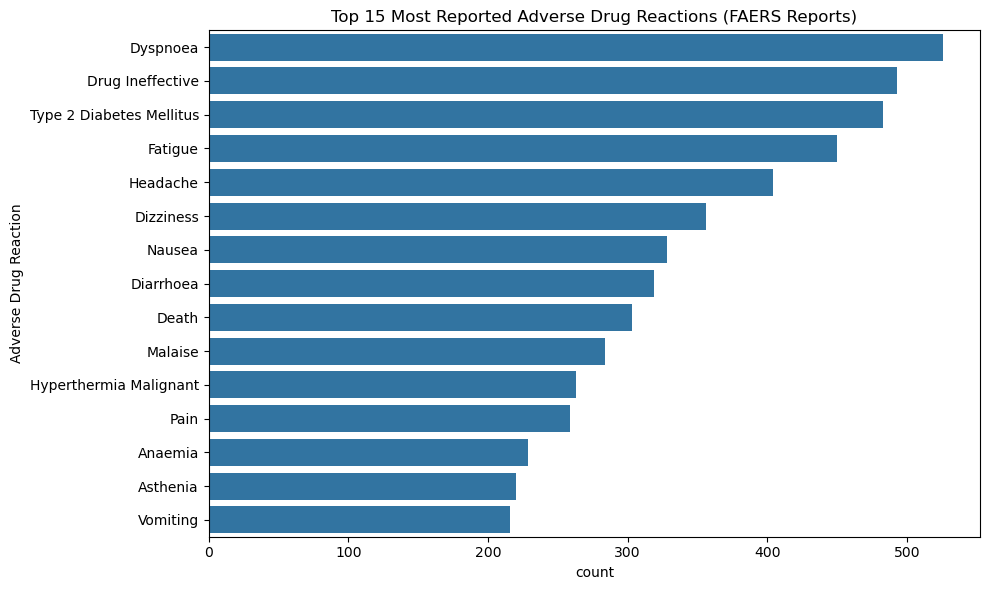

In [56]:
abundant_side_effects=df['reaction'].value_counts().head(15)
abundant_side_effects_df = abundant_side_effects.reset_index(name='count')
abundant_side_effects_df
plt.figure(figsize=(10, 6))
sns.barplot(data=abundant_side_effects_df,x='count',y='reaction')
plt.ylabel('Adverse Drug Reaction')
plt.title('Top 15 Most Reported Adverse Drug Reactions (FAERS Reports)')
plt.tight_layout()
plt.savefig('Top 15 Most Reported Adverse Drug Reactions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Chart analysis
The distribution of reported adverse reactions shows that Drug Ineffective and Dyspnoea are among the most frequently reported reactions in the dataset. Common non‑specific symptoms such as Headache, Nausea, and Vomiting also appear among the most reported reactions, which is consistent with patterns typically observed in pharmacovigilance databases.

Interestingly, Type 2 Diabetes Mellitus appears relatively frequently among the reported reactions. This may reflect metabolic effects associated with certain medications in the dataset or the reporting of underlying conditions within FAERS reports. Further analysis linking reactions with specific drugs would be required to better interpret this pattern.

In [57]:
age_abundant_se=df.set_index('reaction').loc[abundant_side_effects_df['reaction'],'age_group']
age_abundant_se=age_abundant_se.reset_index(name='age_group')
age_abundant_se_df=age_abundant_se.value_counts(subset=['reaction', 'age_group']).reset_index()
age_abundant_se_df

,reaction,age_group,count
0,Hyperthermia Malignant,unknown,263
1,Type 2 Diabetes Mellitus,unknown,228
2,Dyspnoea,Senior,211
3,Drug Ineffective,unknown,210
4,Type 2 Diabetes Mellitus,Middle Age,199
...,...,...,...
76,Death,Child,2
77,Asthenia,Adolescent,1
78,Asthenia,Child,1
79,Anaemia,Adolescent,1


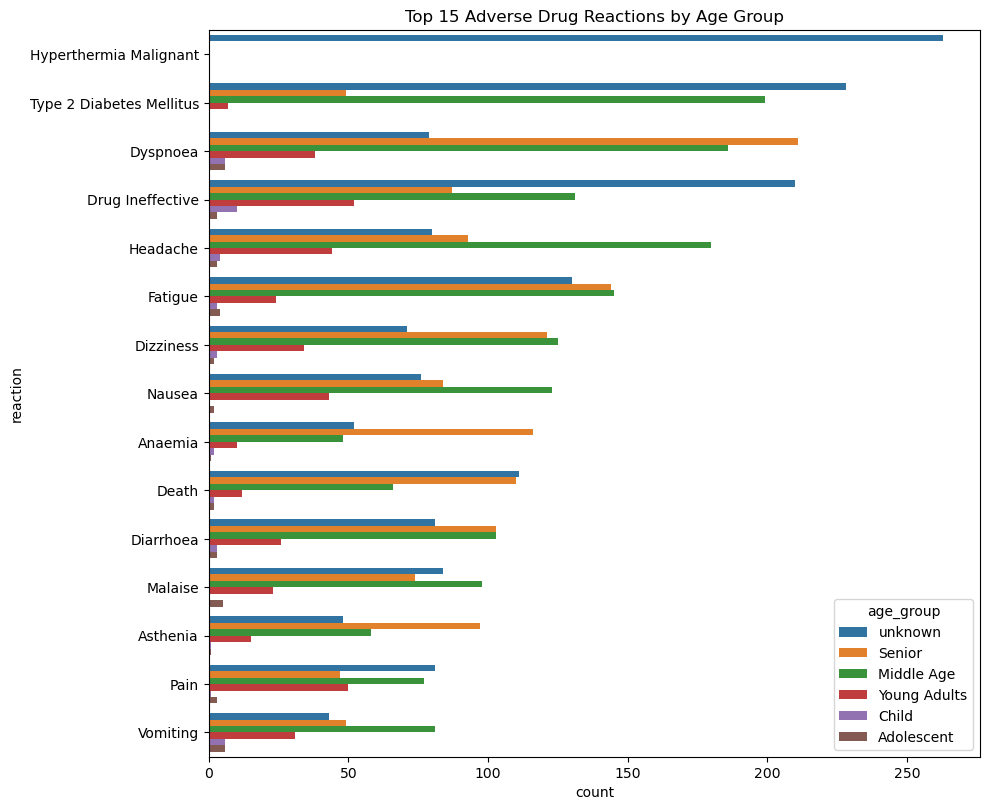

In [58]:
plt.figure(figsize=(10,8))
sns.barplot(data=age_abundant_se_df,x='count',y='reaction',hue='age_group')
plt.tight_layout()
plt.title('Top 15 Adverse Drug Reactions by Age Group')
plt.savefig('Top 15 Adverse Drug Reactions by Age Group.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Analysis of Adverse Reactions by Age Group
"The analysis of adverse reaction distribution across age groups reveals that the Middle Age and Senior populations account for the vast majority of reports. A significant observation is that the Middle Age group shows higher reporting frequencies than Seniors in specific categories, most notably for Headache and Type 2 Diabetes Mellitus.

While the Young Adults group generally has lower representation across the dataset, they show a relatively higher involvement in reports related to Pain and Headache, suggesting these systemic symptoms are their most common reasons for reporting.

Furthermore, the data highlights a data quality issue regarding Hyperthermia Malignant, where nearly all reports fall into the Unknown age category. This suggests a specific cluster of reports or a source that consistently omits demographic details. Overall, the dominance of older age groups likely reflects higher medication exposure (polypharmacy) and increased sensitivity to drug-induced metabolic and systemic changes."

In [59]:
df.head()

,safety_report_id,transmission_date,serious,seriousness_death,received_date,age,sex,reporter_country,reaction,drug_details,age_group
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,Drug Administration Error,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,Overdose,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Vomiting,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Diarrhoea,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Arthralgia,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior


In [60]:
#changing drug details structure so we can explode drug names from it
df['drug_details_2']=df['drug_details'].apply(ast.literal_eval)
df.head()
df=df.explode('drug_details_2')
df['drug_name'] = [x.get('drug_name') for x in df['drug_details_2']]

In [61]:
df.head()

,safety_report_id,transmission_date,serious,seriousness_death,received_date,age,sex,reporter_country,reaction,drug_details,age_group,drug_details_2,drug_name
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,Drug Administration Error,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults,"{'drug_name': 'DURAGESIC-100', 'drug_indicatio...",DURAGESIC-100
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,Overdose,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults,"{'drug_name': 'DURAGESIC-100', 'drug_indicatio...",DURAGESIC-100
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Vomiting,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior,"{'drug_name': 'BONIVA', 'drug_indication': 'OS...",BONIVA
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Diarrhoea,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior,"{'drug_name': 'BONIVA', 'drug_indication': 'OS...",BONIVA
1,10003300,2014-10-02,Serious,Not reported,2014-03-06,77.0,Female,US,Arthralgia,"[{'drug_name': 'BONIVA', 'drug_indication': 'O...",Senior,"{'drug_name': 'BONIVA', 'drug_indication': 'OS...",BONIVA


In [62]:
#cleaning drug name column for later analyse
df['drug_name'] = df['drug_name'].str.title()
display(df['drug_name'].isna().sum())
(df['drug_name'].astype(str).str.strip() == "").sum()


np.int64(0)

np.int64(0)

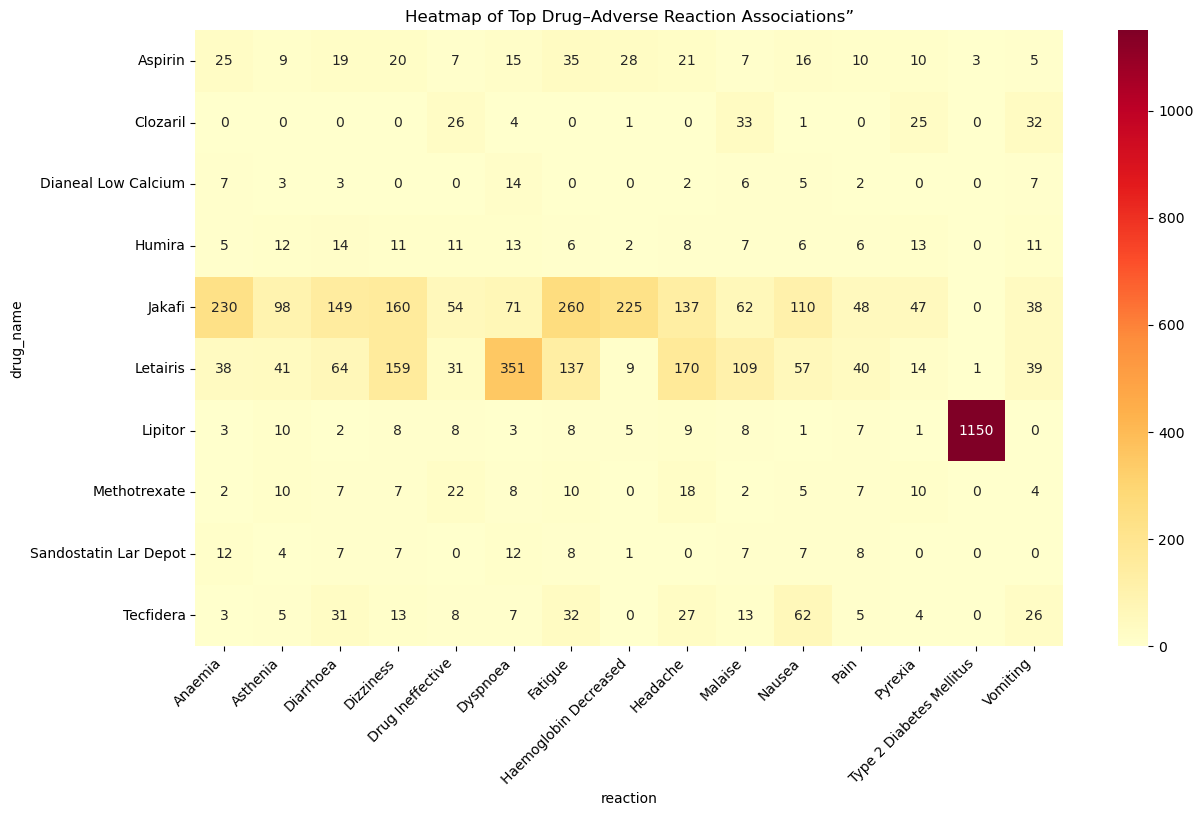

In [63]:
#drawing heatmap plot that shows the relation between 10 most used drug in this data and 15 most abundant reactions
#check another time to learn the code entirely
top_drugs = df['drug_name'].value_counts().head(10).index
top_reactions = df['reaction'].value_counts().head(15).index

heat_df = df[df['drug_name'].isin(top_drugs) & df['reaction'].isin(top_reactions)]

heatmap_df = heat_df.groupby(['drug_name', 'reaction']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_df, annot=True, fmt='g', cmap='YlOrRd')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Heatmap of Top Drug–Adverse Reaction Associations”')
plt.savefig('drug_reaction_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [64]:
#percentage of cases that leads to death
death_cases=df.loc[(df['seriousness_death']=='Death'),:]

print(f'percentage of cases that leads to death : {len(death_cases)/len(df)*100:.2f}%')

percentage of cases that leads to death : 9.72%


In [65]:
death_cases.head()

,safety_report_id,transmission_date,serious,seriousness_death,received_date,age,sex,reporter_country,reaction,drug_details,age_group,drug_details_2,drug_name
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,Drug Administration Error,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults,"{'drug_name': 'DURAGESIC-100', 'drug_indicatio...",Duragesic-100
0,5801206-7,2009-01-09,Serious,Death,2008-07-07,26.0,Male,CANADA,Overdose,"[{'drug_name': 'DURAGESIC-100', 'drug_indicati...",Young Adults,"{'drug_name': 'DURAGESIC-100', 'drug_indicatio...",Duragesic-100
15,10003315,2014-10-02,Serious,Death,2014-03-12,NaN,Male,US,Death,"[{'drug_name': 'RANOLAZINE', 'drug_indication'...",unknown,"{'drug_name': 'RANOLAZINE', 'drug_indication':...",Ranolazine
18,10003318,2014-12-12,Serious,Death,2014-03-12,59.0,Female,BR,Tuberculosis Of Central Nervous System,"[{'drug_name': 'BELIMUMAB', 'drug_indication':...",Middle Age,"{'drug_name': 'BELIMUMAB', 'drug_indication': ...",Belimumab
18,10003318,2014-12-12,Serious,Death,2014-03-12,59.0,Female,BR,Tuberculosis Of Central Nervous System,"[{'drug_name': 'BELIMUMAB', 'drug_indication':...",Middle Age,"{'drug_name': 'AZATHIOPRINE', 'drug_indication...",Azathioprine


In [66]:
# studied the top 10  reaction that leads to death
death_cases_reaction_not_death=df.loc[(df['seriousness_death']=='Death')&(df['reaction']!='Death'),:]
dangerous_reactions=death_cases_reaction_not_death.groupby('reaction')['seriousness_death'].count().sort_values(ascending=False).head(10)
dangerous_reactions_df=dangerous_reactions.reset_index()
dangerous_reactions_df

,reaction,seriousness_death
0,Disease Progression,149
1,Pneumonia,147
2,Fall,141
3,Vomiting,117
4,Diarrhoea,111
5,Anaemia,109
6,Drug Ineffective,101
7,Respiratory Failure,97
8,Dyspnoea,94
9,Malaise,93


In [67]:
print(f'average age of people who died and had fall reaction : {df['age'].mean():.1f}')
print(f'fall percentage in top 10 reaction that leads to death : {(dangerous_reactions_df['reaction']=='Fall').sum()/len(dangerous_reactions_df)*100}%')

average age of people who died and had fall reaction : 57.3
fall percentage in top 10 reaction that leads to death : 10.0%


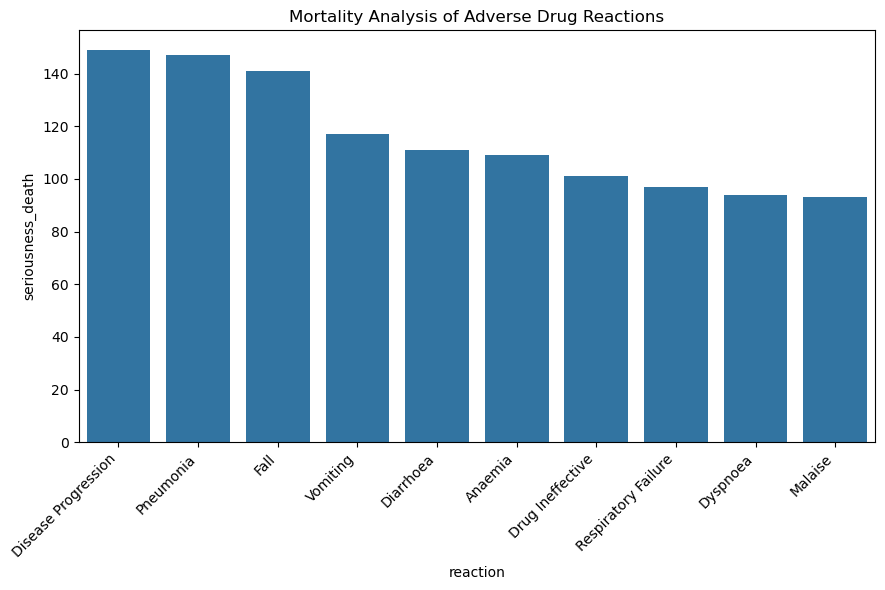

In [68]:
# plot of top 10  drugs that leads to death
plt.figure(figsize=(9,6))
sns.barplot(data=dangerous_reactions_df,x='reaction',y='seriousness_death')
plt.xticks(rotation=45, ha='right')
plt.title('Mortality Analysis of Adverse Drug Reactions')
plt.tight_layout()
plt.savefig('Mortality Analysis of Adverse Drug Reactions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### plot explanition
1-the big number of fall(10 percent) can shows that this dataset has been gathered in ptoximately old people also we can say this dataset contains many serios patients and because of thaat drugs couldnt stop the diseas
2-pneumonia and dyspnoea being in most frequednt reaction shows the importance of Respiratory system and vomiting and diarrhoe Abundance shows how important are they despite of peoples imanigaton
3-number of top 10 reactions are fairly close together it can show variety in datacases

In [69]:
#reviewing the average age that has fall reaction in dataset
age_in_fall_reaction=df.loc[df['reaction'] == 'Fall', 'age'].reset_index()
age_in_fall_reaction

,index,age
0,23,73.0
1,114,52.0
2,129,10.0
3,129,10.0
4,129,10.0
...,...,...
873,9757,82.0
874,9757,82.0
875,9875,75.0
876,9875,75.0


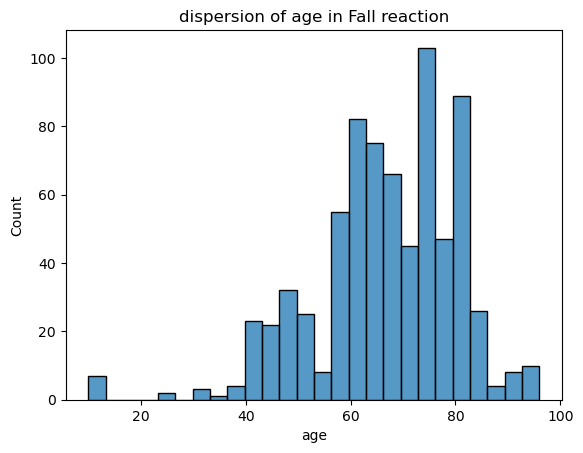

In [70]:
sns.histplot(data=age_in_fall_reaction,x='age')
plt.title('dispersion of age in Fall reaction')
plt.savefig('dispersion of age in Fall reaction.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### fall reaction analyse
this histogram shows that the majority of fall reaction occure in elderly population(60 to 90 years old)

fall is abundant adverse reaction in elderly and also it has 10% share in deaths that shows its severity in elderly population

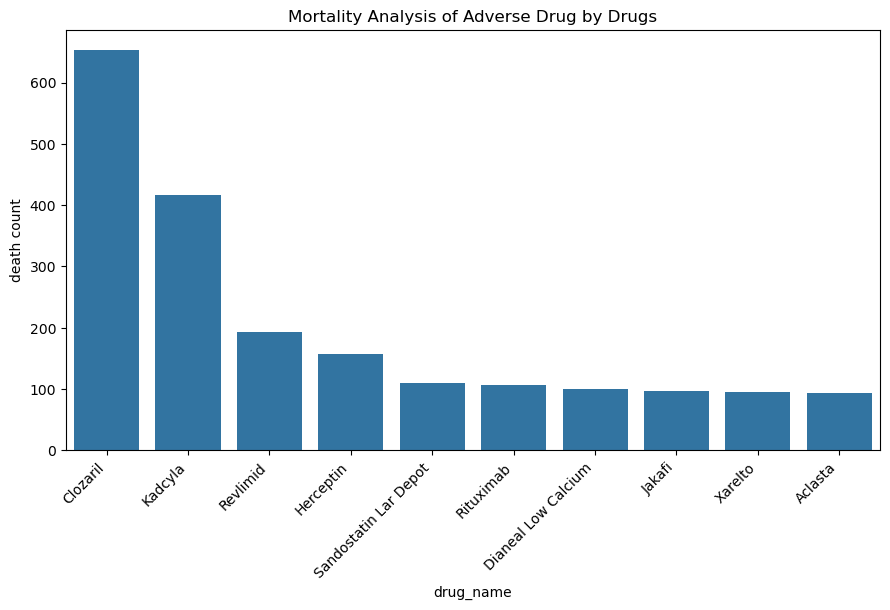

In [71]:
# studied the top 10  drugs that leads to death
most_hurtfull_drugs=death_cases['drug_name'].value_counts().head(10).reset_index()
most_hurtfull_drugs
plt.figure(figsize=(9,6))
sns.barplot(data=most_hurtfull_drugs,x='drug_name',y='count')
plt.ylabel('death count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title('Mortality Analysis of Adverse Drug by Drugs')
plt.savefig('Mortality Analysis of Adverse Drug by Drugs.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### plot explanition
The chart clearly indicates that Clozaril (Clozapine) and Kadcyla (ado-trastuzumab emtansine) have the highest recorded mortality rates
among all drugs in this dataset. This significant finding highlights that while these medications are essential for treating severe conditions 
(refractory schizophrenia and HER2-positive breast cancer, respectively), they carry substantial life-threatening risks.
Consequently, their clinical use demands strict patient monitoring and regular laboratory testing to mitigate fatal outcomes.



In [72]:
# studing death in diffrent sex groups
sex_groups_death_cases=death_cases['sex'].value_counts().reset_index()
sex_groups_death_cases

,sex,count
0,Female,6672
1,Male,3451
2,Unknown,644
3,Missing,456


In [73]:
total = sex_groups_death_cases['count'].sum()

for sex, count in zip(sex_groups_death_cases['sex'], sex_groups_death_cases['count']):
    print(f'{sex} percentage : {count / total * 100:.2f}%')



Female percentage : 59.45%
Male percentage : 30.75%
Unknown percentage : 5.74%
Missing percentage : 4.06%


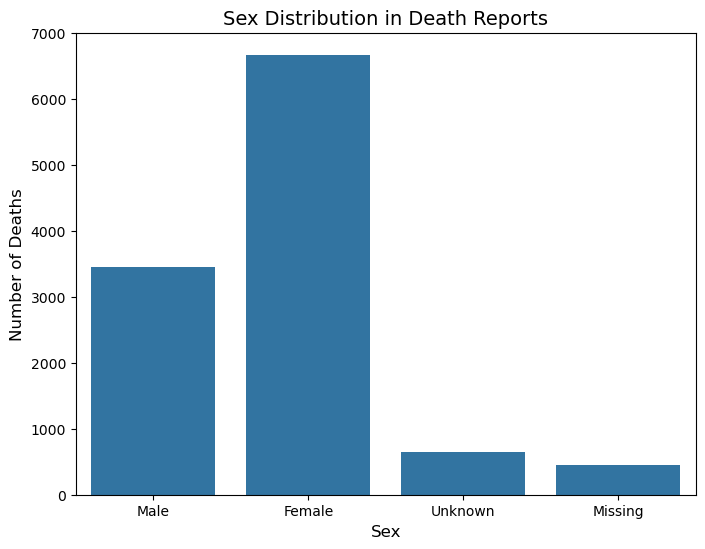

In [74]:
plt.figure(figsize=(8, 6))
sns.barplot(data=sex_groups_death_cases, x='sex', y='count', order=['Male', 'Female', 'Unknown', 'Missing'])
plt.title('Sex Distribution in Death Reports', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.savefig('Sex Distribution in Death Reports.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### gendet_death reaction analyse
according to dataset about 60 percent of deaths are female and 30 percent are male. based on this data we can say in this dataset The majority of deaths are among women. 

"A significant number of death reports (9.8 percent) lack valid gender information (Missing/Unknown), which may indicate challenges in data recording in emergency cases and limit the generalizability of the results."

In [75]:
age_groups_death_cases=death_cases['age_group'].value_counts().reset_index()
age_groups_death_cases

,age_group,count
0,Middle Age,4795
1,Senior,3304
2,unknown,1896
3,Young Adults,836
4,Child,352
5,Adolescent,40


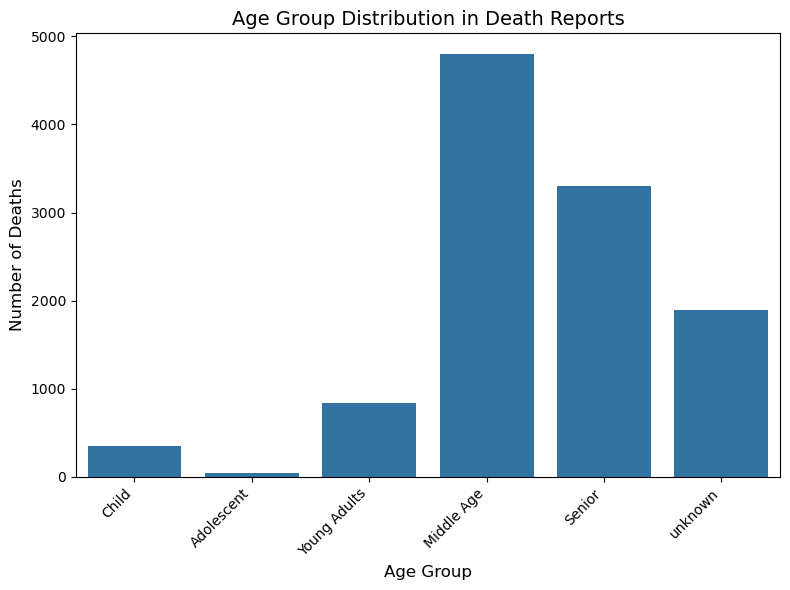

In [76]:
plt.figure(figsize=(8, 6))
sns.barplot(data=age_groups_death_cases, x='age_group', y='count', order=['Child', 'Adolescent', 'Young Adults', 'Middle Age', 'Senior', 'unknown'])
plt.title('Age Group Distribution in Death Reports', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Age Group Distribution in Death Reports.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### plot analyse
Age Distribution in Death Reports:

The analysis of age distribution among death reports revealed that the Middle Age group (40–65 years) had the highest frequency of deaths, surpassing even the Senior group (>65 years). This observation, while initially counterintuitive, can be explained by several clinical and data‑related factors:

Treatment Intensity: Middle‑aged patients often receive more aggressive treatment regimens, including higher drug doses and combination therapies, particularly in oncology and autoimmune diseases. This increases the risk of fatal adverse drug reactions.

Reporting Bias (Attribution of Cause): In elderly patients, death is frequently attributed to underlying comorbidities, frailty, or natural disease progression rather than to a specific adverse drug reaction. Conversely, death in a middle‑aged patient is more likely to be investigated and reported as a potential drug‑related event, leading to higher reporting rates in this group.

High Proportion of Missing Data: It is important to note that the Unknown group (1,896 reports) had the highest frequency, reflecting significant data quality issues in age recording. Therefore, the above conclusion is based only on cases with known age and may change if age information for the unknown group becomes available.



## Summary
This dataset contained various information, including adverse drug reactions, mortality data, and drug names. In this project, we analyzed the most frequent adverse reactions, examined their relationship with different age groups, and identified the most hazardous drugs. We also studied mortality rates and their association with common reactions, revealing interesting patterns. Additionally, we investigated the impact of top drugs on death counts and explored the relationship between mortality and age groups as well as sex.



## key points
The most common adverse reactions were Diarrhea, Nausea, and Fatigue. After examining the relationship between reactions and drugs, we found that Jakafi was associated with several reactions, and the most common reaction among frequently prescribed drugs was Type 2 Diabetes Mellitus, linked to Lantus.

In mortality analysis, the most frequent reaction preceding death was Disease Progression, indicating a high number of severely ill patients in the dataset. The notable frequency of Fall also suggests a significant elderly population.

Clozaril and Kadcyla were identified as the most dangerous drugs based on death statistics.

Of the total death reports, 59.4% were female, 30.8% were male, and 9.8% had missing/unknown gender information.

Interestingly, deaths in the Middle Age group (40–65 years) outnumbered those in the Senior group (>65 years). This may be due to more aggressive treatment regimens in middle‑aged patients and potential under‑reporting of drug‑related deaths in the elderly.

A substantial proportion of age data (33.5%) was recorded as unknown, highlighting a data quality issue in age reporting.